In [1]:
# ============================================================
# SKEMPI benchmarking with TRUE ΔH labels from binding_affinity_deltaH.txt
# - ESM OFF
# - Computes metrics: R2, PearsonR, Spearman, MAE, RMSE
# - No file writes
# ============================================================

import os, re, glob, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
except Exception as e:
    print("[WARN] torch not available; PT feature loading will fail:", e)
    torch = None

# ---------------------------
# PATHS (same as your model)
# ---------------------------
CSV_A      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
FEAT_DIR   = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"
PDB_TXT    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
TARGETS    = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_deltaH.txt"
SASA_PATH  = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/all_pdb_sasa.txt"

MODEL_PATH = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/model/deltaH_combo_model.joblib"
SKEMPI_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/model/benchmarking/skempi1.1/SKEMPI_pdbs"

FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]  # 94

# ---------------------------
# Helpers
# ---------------------------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols:
            return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)

    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")

    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def to_1d_numpy(x) -> np.ndarray:
    if torch is not None and isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    elif isinstance(x, dict):
        keys = {k.lower(): k for k in x.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(x[keys[k]])
        for _, v in x.items():
            try:
                return to_1d_numpy(v)
            except Exception:
                continue
        raise ValueError("No usable feature array found in dict payload.")
    else:
        raise TypeError(f"Unsupported payload type: {type(x)}")

    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    if arr.ndim > 1:
        arr = arr.reshape(-1)
    return arr

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    if torch is None:
        raise RuntimeError("torch not available to load PT features.")
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}")
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return to_1d_numpy(obj)

def load_sasa_table(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]

    if "total_sasa_A2" not in df.columns:
        for alt in ("total_sasa", "total_sasa_A^2", "total_sasa_A²", "sasa_total_A2"):
            if alt in df.columns:
                df = df.rename(columns={alt: "total_sasa_A2"})
                break
    if "total_sasa_A2" not in df.columns:
        raise ValueError(f"SASA file missing 'total_sasa_A2' (got: {list(df.columns)})")

    cand1 = df["pdb_id"].astype(str).map(normalize_pdb_id) if "pdb_id" in df.columns else None
    cand2 = None
    if "file" in df.columns:
        def id_from_path(p: str) -> str:
            m = re.search(r'([0-9A-Za-z]{4})', str(p))
            return m.group(1).lower() if m else ""
        cand2 = df["file"].astype(str).map(id_from_path)

    if cand1 is not None and cand2 is not None:
        join_id = np.where(cand1.str.fullmatch(r"[0-9a-z]{4}", na=False), cand1, cand2)
    elif cand1 is not None:
        join_id = cand1
    elif cand2 is not None:
        join_id = cand2
    else:
        raise ValueError("No usable ID source in SASA file (need 'pdb_id' or 'file').")

    df = df.assign(JOIN_ID=join_id)
    df = df[df["JOIN_ID"].str.fullmatch(r"[0-9a-z]{4}", na=False)].copy()
    df["total_sasa_A2"] = pd.to_numeric(df["total_sasa_A2"], errors="coerce")
    df = df.groupby("JOIN_ID", as_index=True)["total_sasa_A2"].mean(numeric_only=True).to_frame()
    return df.sort_index()

def load_targets_deltaH(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    if "PDB_ID" in df.columns and "pdb_id" not in df.columns:
        df = df.rename(columns={"PDB_ID": "pdb_id"})
    for col in ("Delta_H", "ΔH_kJ/mol", "dH"):
        if col in df.columns and "delta_H" not in df.columns:
            df = df.rename(columns={col: "delta_H"})
    if "pdb_id" not in df.columns or "delta_H" not in df.columns:
        raise ValueError(f"Targets must contain pdb_id and delta_H. Got cols: {list(df.columns)}")
    df["JOIN_ID"] = df["pdb_id"].apply(normalize_pdb_id)
    df["delta_H"] = pd.to_numeric(df["delta_H"], errors="coerce")
    return df.set_index("JOIN_ID")[["delta_H"]].sort_index()

def metrics_block(y, p):
    y = np.asarray(y).ravel()
    p = np.asarray(p).ravel()
    mse = mean_squared_error(y, p)
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y, p))
    r2 = float(r2_score(y, p))
    R = float(pearsonr(y, p)[0]) if len(y) >= 2 else float("nan")
    rho = float(spearmanr(y, p)[0]) if len(y) >= 2 else float("nan")
    return dict(R2=r2, PearsonR=R, Spearman=rho, MAE=mae, RMSE=rmse)

# ---------------------------
# 1) IDs from SKEMPI dir
# ---------------------------
pdb_files = sorted(glob.glob(os.path.join(SKEMPI_DIR, "*.pdb")))
raw_ids = [os.path.splitext(os.path.basename(p))[0].strip() for p in pdb_files]
skempi_ids = [normalize_pdb_id(x) for x in raw_ids]
skempi_ids = [i for i in skempi_ids if re.fullmatch(r"[0-9a-z]{4}", i)]

print(f"[SKEMPI] Found {len(pdb_files)} .pdb files; parsed {len(skempi_ids)} valid IDs.")
print("[SKEMPI] Example IDs:", skempi_ids[:10])

# ---------------------------
# 2) Filter by TXT allowlist
# ---------------------------
allowed = load_id_list(PDB_TXT)
ids_txt = sorted(set([i for i in skempi_ids if i in allowed]))
print(f"[TXT] In allowlist: {len(ids_txt)} / {len(set(skempi_ids))}")
if not ids_txt:
    raise RuntimeError("No SKEMPI IDs are in the model TXT allowlist.")

# ---------------------------
# 3) Load ΔH targets; keep only labeled SKEMPI IDs
# ---------------------------
df_y = load_targets_deltaH(TARGETS)  # index=JOIN_ID, col=delta_H
ids_lbl = [i for i in ids_txt if i in df_y.index and pd.notna(df_y.loc[i, "delta_H"])]
print(f"[TARGETS] Labeled (ΔH present): {len(ids_lbl)} / {len(ids_txt)}")

if not ids_lbl:
    raise RuntimeError("None of the SKEMPI allowlisted IDs have ΔH labels in TARGETS.")

# ---------------------------
# 4) Load model bundle
# ---------------------------
bundle = joblib.load(MODEL_PATH)
rf   = bundle["rf"]
et   = bundle["et"]
hgb  = bundle["hgb"]
meta = bundle["meta"]

pt_dim = bundle.get("pt_dim", None)
use_sasa = bool(bundle.get("use_sasa", False))
use_esm  = bool(bundle.get("use_esm", False))
extra_scalar_cols = bundle.get("extra_scalar_cols", []) or []
bf_cols = bundle.get("bf_cols", []) or []

print(f"[MODEL] PT dim={pt_dim} | use_sasa={use_sasa} | use_esm={use_esm} | extra_scalars={extra_scalar_cols} | bf_cols={bf_cols}")
if use_esm:
    raise RuntimeError("Your saved model says ESM was used, but your setup is ESM OFF. Use matching model bundle.")

# ---------------------------
# 5) Load CSV A/B and filter IDs present there
# ---------------------------
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

ids_csv = [i for i in ids_lbl if (i in df_a.index and i in df_b.index)]
print(f"[CSV] Present in BOTH A and B: {len(ids_csv)} / {len(ids_lbl)}")
if not ids_csv:
    raise RuntimeError("No labeled SKEMPI IDs are present in both CSV_A and CSV_B.")

# ---------------------------
# 6) Load PT vectors and keep correct length
# ---------------------------
PT_list, ids_pt = [], []
for pid in ids_csv:
    v = load_pt_vector(FEAT_DIR, pid)
    if pt_dim is not None and len(v) != pt_dim:
        continue
    PT_list.append(v)
    ids_pt.append(pid)

print(f"[PT] Loaded PT: {len(ids_pt)} / {len(ids_csv)}")
if not ids_pt:
    raise RuntimeError("No PT vectors loaded after filtering.")

PT = np.vstack(PT_list).astype(np.float64)

# ---------------------------
# 7) Scalars (SASA + complex_count etc.)
#    - SASA joined if available
#    - complex_count not available from SKEMPI PDBs; set to 1.0 (recommended)
# ---------------------------
df_scalar = pd.DataFrame(index=ids_pt)

if use_sasa:
    df_sasa = load_sasa_table(SASA_PATH)  # has total_sasa_A2
    df_scalar = df_scalar.join(df_sasa, how="left")
    df_scalar["total_sasa_kA2"] = df_scalar["total_sasa_A2"] / 1000.0
    print("[SASA] Missing total_sasa_A2:", int(df_scalar["total_sasa_A2"].isna().sum()), "/", len(df_scalar))

# Provide complex_count as 1.0 for single-PDB benchmarks (avoids imputation drift)
if "complex_count" in extra_scalar_cols and "complex_count" not in df_scalar.columns:
    df_scalar["complex_count"] = 1.0

# Ensure expected scalar cols exist (NaN ok; pipeline imputes)
for c in extra_scalar_cols:
    if c not in df_scalar.columns:
        df_scalar[c] = np.nan
for c in bf_cols:
    if c not in df_scalar.columns:
        df_scalar[c] = np.nan

# ---------------------------
# 8) Build X (ESM OFF)
# ---------------------------
A = df_a.loc[ids_pt, FEATURE_COLS].to_numpy(dtype=np.float64)
B = df_b.loc[ids_pt, FEATURE_COLS].to_numpy(dtype=np.float64)

SUM   = A + B
DIFF  = A - B
ADIFF = np.abs(DIFF)
PROD  = A * B
COS   = ((A * B).sum(axis=1) /
         (np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1) + 1e-8)).reshape(-1, 1)
RATIO = DIFF / (SUM + 1e-8)

parts = [A, B, SUM, DIFF, ADIFF, PROD, COS, RATIO, PT]
if extra_scalar_cols:
    parts.append(df_scalar.loc[ids_pt, extra_scalar_cols].to_numpy(dtype=np.float64))
if bf_cols:
    parts.append(df_scalar.loc[ids_pt, bf_cols].to_numpy(dtype=np.float64))

X = np.hstack(parts).astype(np.float64)
y = df_y.loc[ids_pt, "delta_H"].to_numpy(dtype=np.float64)

print("[X,y] Shapes:", X.shape, y.shape)

# ---------------------------
# 9) Predict
# ---------------------------
p_rf  = rf.predict(X)
p_et  = et.predict(X)
p_hgb = hgb.predict(X)

p_bl3 = (p_rf + p_et + p_hgb) / 3.0

meta_X = np.column_stack([
    p_rf, p_et, p_hgb,
    (p_rf + p_et + p_hgb) / 3.0,
    p_rf - p_et,
    p_rf - p_hgb,
    p_et - p_hgb
])
p_stack = meta.predict(meta_X)

# ---------------------------
# 10) Metrics report
# ---------------------------
rows = []
for name, p in [("RF", p_rf), ("ET", p_et), ("HGB", p_hgb), ("Blend3", p_bl3), ("Stack", p_stack)]:
    m = metrics_block(y, p)
    rows.append({"model": name, **m})

df_metrics = pd.DataFrame(rows).set_index("model")
print("\n=== SKEMPI BENCHMARK METRICS (ΔH) ===")
print(df_metrics)

# ---------------------------
# 11) Per-sample table (for inspection)
# ---------------------------
df_eval = pd.DataFrame({
    "JOIN_ID": ids_pt,
    "delta_H": y,
    "pred_rf": p_rf,
    "pred_et": p_et,
    "pred_hgb": p_hgb,
    "pred_blend3": p_bl3,
    "pred_stack": p_stack,
    "has_sasa": (~df_scalar.get("total_sasa_A2", pd.Series(index=ids_pt, data=np.nan)).isna()).astype(int).values
}).set_index("JOIN_ID").sort_index()

print("\n[Eval head]")
print(df_eval.head(10))

print("\n[DONE] Evaluated on", len(df_eval), "SKEMPI IDs with ΔH labels.")

# df_metrics and df_eval are now available in memory


[SKEMPI] Found 158 .pdb files; parsed 158 valid IDs.
[SKEMPI] Example IDs: ['1a22', '1a4y', '1acb', '1ahw', '1ak4', '1b2s', '1b2u', '1b3s', '1brs', '1cbw']
[TXT] In allowlist: 84 / 158
[TARGETS] Labeled (ΔH present): 84 / 84
[MODEL] PT dim=1440 | use_sasa=True | use_esm=False | extra_scalars=['complex_count', 'total_sasa_kA2'] | bf_cols=[]
[CSV] Present in BOTH A and B: 84 / 84
[PT] Loaded PT: 84 / 84
[SASA] Missing total_sasa_A2: 0 / 84
[X,y] Shapes: (84, 2101) (84,)

=== SKEMPI BENCHMARK METRICS (ΔH) ===
              R2  PearsonR  Spearman       MAE       RMSE
model                                                    
RF      0.806065  0.932118  0.932099  4.637079   6.694058
ET      0.915339  0.963446  0.961400  2.468284   4.422853
HGB     0.360103  0.766132  0.805864  8.633574  12.159530
Blend3  0.768236  0.929029  0.933425  4.997588   7.317869
Stack   0.723067  0.910852  0.925832  5.779250   7.999252

[Eval head]
         delta_H    pred_rf    pred_et   pred_hgb  pred_blend3  pred_

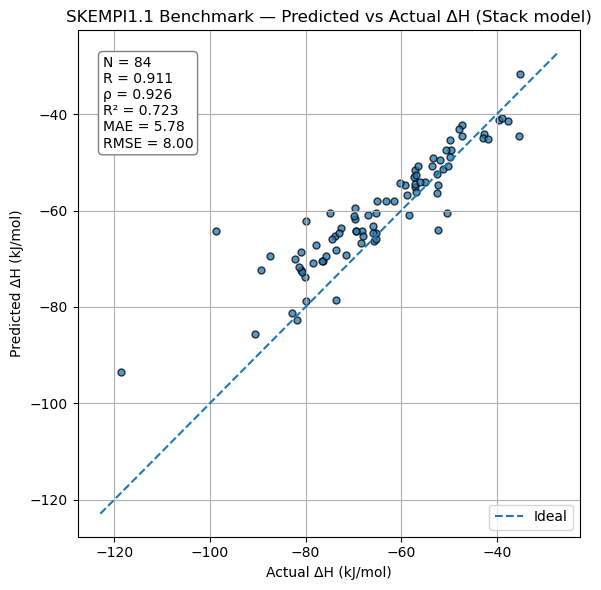

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

# --- Select data ---
y_true = df_eval["delta_H"].values
y_pred = df_eval["pred_stack"].values   # change to pred_blend3 if desired

# --- Metrics ---
R = pearsonr(y_true, y_pred)[0]
rho = spearmanr(y_true, y_pred)[0]
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.75, edgecolor="k", s=25)

mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
pad = 0.05 * (mx - mn)
plt.plot([mn - pad, mx + pad], [mn - pad, mx + pad], "--", label="Ideal")

plt.xlabel("Actual ΔH (kJ/mol)")
plt.ylabel("Predicted ΔH (kJ/mol)")
plt.title("SKEMPI1.1 Benchmark — Predicted vs Actual ΔH (Stack model)")

txt = (
    f"N = {len(y_true)}\n"
    f"R = {R:.3f}\n"
    f"ρ = {rho:.3f}\n"
    f"R² = {r2:.3f}\n"
    f"MAE = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}"
)

plt.annotate(
    txt,
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"),
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [1]:
import os, re
from pathlib import Path

PDB_TXT = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
BENCH_PDB_DIR = "/home/op98/protein_design/mGLI-pp_Oleksii/model/benchmarking/skempi1.1/SKEMPI_pdbs"

OUT_DIR = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files"
BENCH_TXT = f"{OUT_DIR}/benchmark_ids_skempi.txt"
NONOVERLAP_TXT = f"{OUT_DIR}/1619_ids_no_skempi.txt"

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            token = s.split()[0]
            pid = normalize_pdb_id(token)
            if re.fullmatch(r"[0-9a-z]{4}", pid):
                ids.append(pid)
    return set(ids)

def load_benchmark_ids_from_pdb_dir(pdb_dir: str) -> set[str]:
    ids = set()
    for root, _, files in os.walk(pdb_dir):
        for fn in files:
            if fn.lower().endswith(".pdb"):
                pid = normalize_pdb_id(fn)
                if re.fullmatch(r"[0-9a-z]{4}", pid):
                    ids.add(pid)
    return ids

def write_id_list(path: str, ids: set[str]) -> None:
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        for i in sorted(ids):
            f.write(i + "\n")

orig_ids = load_id_list(PDB_TXT)
bench_ids = load_benchmark_ids_from_pdb_dir(BENCH_PDB_DIR)

if not bench_ids:
    raise RuntimeError(f"No benchmark IDs found in {BENCH_PDB_DIR}")

nonoverlap_ids = orig_ids - bench_ids
if not nonoverlap_ids:
    raise RuntimeError("All original IDs overlap with benchmark set; non-overlap is empty.")

write_id_list(BENCH_TXT, bench_ids)
write_id_list(NONOVERLAP_TXT, nonoverlap_ids)

print("Wrote:")
print("  BENCH_TXT     =", BENCH_TXT, "(", len(bench_ids), "IDs )")
print("  NONOVERLAP_TXT=", NONOVERLAP_TXT, "(", len(nonoverlap_ids), "IDs )")
print("Overlap removed =", len(orig_ids & bench_ids))


Wrote:
  BENCH_TXT     = /home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/benchmark_ids_skempi.txt ( 158 IDs )
  NONOVERLAP_TXT= /home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids_no_skempi.txt ( 1533 IDs )
Overlap removed = 84


[INFO] Using 1533/1831 target rows present in TXT (1533 allowed IDs).
[SASA] df_t IDs: 1533 | SASA IDs: 1462 | Intersection: 827
[INFO] SASA merged; missing=706
[INFO] Using PT vectors of length 1440; dropped 0 non-mode samples.
A: (1533, 94) B: (1533, 94) PT: (1533, 1440) ESM:OFF  Targets: (1533, 7) Common: 1533
Shapes -> X_tr:(1073, 2101), X_va:(230, 2101), X_te:(230, 2101), y_tr:(1073,)

== Validation (base) ==
VAL RF: R2=0.425  PearsonR=0.654  Spearman=0.641  MAE=7.99  RMSE=10.56  MSE=111.55
VAL ET: R2=0.415  PearsonR=0.645  Spearman=0.642  MAE=7.98  RMSE=10.65  MSE=113.48
VAL HGB: R2=0.492  PearsonR=0.703  Spearman=0.660  MAE=7.64  RMSE=9.93  MSE=98.57

== OOF stacking ==
TEST RF: R2=0.477  PearsonR=0.699  Spearman=0.664  MAE=7.19  RMSE=8.97  MSE=80.42
TEST ET: R2=0.463  PearsonR=0.686  Spearman=0.649  MAE=7.24  RMSE=9.09  MSE=82.60
TEST HGB: R2=0.537  PearsonR=0.735  Spearman=0.689  MAE=6.87  RMSE=8.44  MSE=71.22

TEST Stack: R2=0.551  PearsonR=0.746  Spearman=0.694  MAE=6.64  RM

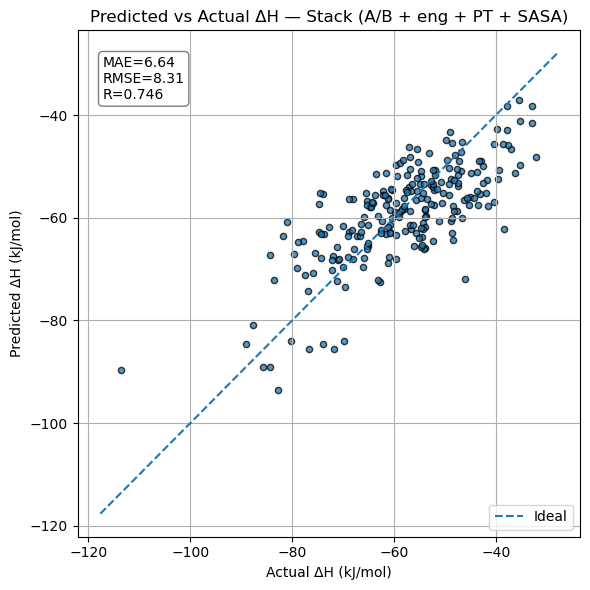

In [12]:
## MODEL RETRAINING WITHOUT SKEMPI IDs
#  ============================================
# ΔH Combo (no file outputs):
# CSV(A/B) + engineered feats + PT(mGLI) + SASA (+ ESM CSV) with delta_H targets
# ============================================

import os, re, sys, math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr, pearsonr

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
except Exception as e:
    print("[WARN] torch not available; PT feature loading will fail:", e)
    torch = None

# ---- PATHS (EDIT) ----
CSV_A      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
CSV_ESM    = "/vast/palmer/home.mccleary/op98/protein_design/dataset/PP/dd_esm_v2020.csv"  # NEW: ESM features
FEAT_DIR   = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # {id}_mGLI.pt
PDB_TXT    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids_no_skempi.txt"
TARGETS    = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_deltaH.txt"  # delta_H targets

# ---- EXTRA (SASA) ----
SASA_PATH        = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/all_pdb_sasa.txt"
USE_SASA_FEATURE = True
USE_ESM_FEATURE  = False   # toggle ESM on/off

# ---- SETTINGS ----
SEED                      = 42
VAL_SPLIT                 = 0.15
TEST_SPLIT                = 0.15
USE_BFACTORS_AS_FEATURES  = True
USE_COMPLEX_COUNT_FEATURE = True
K_BEST                    = 640          # keep as in your original (tune 448–1024 if desired)
WINSORIZE_Y_QUANTILES     = None

# Models (same spirit)
N_TREES_RF = 800
N_TREES_ET = 1000
HGB_CFG = dict(
    learning_rate=0.06, max_depth=4, max_leaf_nodes=63,
    min_samples_leaf=20, l2_regularization=0.2,
    max_bins=255, early_stopping=True,
    validation_fraction=0.15, n_iter_no_change=30, max_iter=1500
)

# Stacking
N_SPLITS_STACK = 5
random.seed(SEED); np.random.seed(SEED)

# ---- CSV utils ----
FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def load_feature_csv_flex(path: str, prefix: str = "feature_") -> pd.DataFrame:
    """ESM CSV may have an arbitrary number of feature_<int> columns."""
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    feat_cols = [c for c in df.columns if c.startswith(prefix) and c[len(prefix):].isdigit()]
    if not feat_cols:
        raise ValueError(f"{path}: no '{prefix}<int>' feature columns found.")
    feat_cols = sorted(feat_cols, key=lambda x: int(x.split("_")[1]))
    for c in feat_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[feat_cols].mean(numeric_only=True)
    return df.sort_index()

# ---- PT utils ----
def to_1d_numpy(x) -> np.ndarray:
    if torch is not None and isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    elif isinstance(x, dict):
        keys = {k.lower(): k for k in x.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys: return to_1d_numpy(x[keys[k]])
        for _, v in x.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    else:
        raise TypeError(f"Unsupported payload type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    if torch is None:
        raise RuntimeError("torch not available to load PT features.")
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}")
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return to_1d_numpy(obj)

# ---- SASA loader (robust, no file writes) ----
def load_sasa_table(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    if "total_sasa_A2" not in df.columns:
        for alt in ("total_sasa", "total_sasa_A^2", "total_sasa_A²", "sasa_total_A2"):
            if alt in df.columns:
                df = df.rename(columns={alt: "total_sasa_A2"})
                break
    if "total_sasa_A2" not in df.columns:
        raise ValueError(f"SASA file missing 'total_sasa_A2' (got: {list(df.columns)})")
    cand1 = df["pdb_id"].astype(str).map(normalize_pdb_id) if "pdb_id" in df.columns else None
    cand2 = None
    if "file" in df.columns:
        def id_from_path(p: str) -> str:
            m = re.search(r'([0-9A-Za-z]{4})', str(p))
            return m.group(1).lower() if m else ""
        cand2 = df["file"].astype(str).map(id_from_path)
    if cand1 is not None and cand2 is not None:
        join_id = np.where(cand1.str.fullmatch(r"[0-9a-z]{4}", na=False), cand1, cand2)
    elif cand1 is not None:
        join_id = cand1
    elif cand2 is not None:
        join_id = cand2
    else:
        raise ValueError("No usable ID source in SASA file (need 'pdb_id' or 'file').")
    df = df.assign(JOIN_ID=join_id)
    df = df[df["JOIN_ID"].str.fullmatch(r"[0-9a-z]{4}", na=False)].copy()
    df["total_sasa_A2"] = pd.to_numeric(df["total_sasa_A2"], errors="coerce")
    df = df.groupby("JOIN_ID", as_index=True)["total_sasa_A2"].mean(numeric_only=True).to_frame()
    return df.sort_index()

# ---- Load targets (ΔH) ----
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns and "pdb_id" not in df_t.columns:
    df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
for col in ("Delta_H", "ΔH_kJ/mol", "dH"):
    if col in df_t.columns and "delta_H" not in df_t.columns:
        df_t = df_t.rename(columns={col: "delta_H"})
for col in ("Delta_G", "ΔG_kJ/mol", "dG"):
    if col in df_t.columns and "delta_G" not in df_t.columns:
        df_t = df_t.rename(columns={col: "delta_G"})
required = ["pdb_id", "delta_H"]
for c in required:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_scalar_cols = []
if USE_COMPLEX_COUNT_FEATURE and "complex_count" in df_t.columns:
    extra_scalar_cols.append("complex_count")
bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]
df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# ---- Filter IDs by TXT ----
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---- Merge SASA into df_t (and register as extra scalar) ----
if USE_SASA_FEATURE:
    try:
        df_sasa = load_sasa_table(SASA_PATH)
        ids_t = set(df_t["JOIN_ID"]); ids_s = set(df_sasa.index)
        inter = ids_t & ids_s
        print(f"[SASA] df_t IDs: {len(ids_t)} | SASA IDs: {len(ids_s)} | Intersection: {len(inter)}")
        df_t = df_t.merge(df_sasa, left_on="JOIN_ID", right_index=True, how="left")
        df_t["total_sasa_kA2"] = df_t["total_sasa_A2"] / 1000.0
        extra_scalar_cols.append("total_sasa_kA2")
        n_missing = df_t["total_sasa_kA2"].isna().sum()
        print(f"[INFO] SASA merged; missing={n_missing}")
    except Exception as e:
        print(f"[WARN] Could not load/merge SASA: {e} — continuing without SASA.")

# ---- Load CSV A/B/ESM ----
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)
if USE_ESM_FEATURE:
    try:
        df_esm = load_feature_csv_flex(CSV_ESM)
        print(f"[ESM] Loaded ESM features with shape {df_esm.shape}")
    except Exception as e:
        print(f"[WARN] Could not load ESM features: {e} — continuing without ESM.")
        USE_ESM_FEATURE = False
        df_esm = None

# ---- Load PT vectors (mGLI) ----
pt_rows, missing, errors = [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        v = load_pt_vector(FEAT_DIR, pid)
        pt_rows.append((pid, v))
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))
if missing:
    print(f"[INFO] Missing PT for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not pt_rows:
    sys.exit("[FATAL] No PT features loaded successfully.")

lengths = [len(v) for _, v in pt_rows]
mode_len = max(set(lengths), key=lengths.count)
pt_rows = [(i, v) for (i, v) in pt_rows if len(v) == mode_len]
print(f"[INFO] Using PT vectors of length {mode_len}; dropped {len(lengths) - len(pt_rows)} non-mode samples.")
pt_index  = [i for i, _ in pt_rows]
pt_matrix = np.vstack([v for _, v in pt_rows])
pt_cols   = [f"pt_{j}" for j in range(mode_len)]
df_pt     = pd.DataFrame(pt_matrix, index=pt_index, columns=pt_cols).sort_index()

# ---- Align: only keep IDs present everywhere
common = set(df_t["JOIN_ID"]) & set(df_a.index) & set(df_b.index) & set(df_pt.index)
if USE_ESM_FEATURE and df_esm is not None:
    common = common & set(df_esm.index)
if not common:
    sys.exit("[FATAL] No common IDs across required sources (targets/CSV/PT[/ESM]).")
if len(common) < len(df_t):
    print(f"[INFO] Dropping {len(df_t)-len(common)} targets not present in all required sources.")

df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)
df_a = df_a.loc[sorted(common)]
df_b = df_b.loc[sorted(common)]
df_pt = df_pt.loc[sorted(common)]
if USE_ESM_FEATURE and df_esm is not None:
    df_esm = df_esm.loc[sorted(common)]

print("A:", df_a.shape, "B:", df_b.shape, "PT:", df_pt.shape,
      "ESM:" if USE_ESM_FEATURE and df_esm is not None else "ESM:OFF",
      (df_esm.shape if USE_ESM_FEATURE and df_esm is not None else ""), "Targets:", df_t.shape,
      "Common:", len(common))
if len(df_t) < 10:
    print("[WARN] Very few samples after filtering—splits may be unstable.")

# ---- Build feature matrix (A/B engineered + PT + optional ESM + scalars)
A_all  = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all  = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
PT_all = df_pt.loc[df_t["JOIN_ID"], pt_cols].to_numpy(dtype=np.float64)
y_all  = df_t["delta_H"].to_numpy(dtype=np.float64).reshape(-1, 1)

# Engineered interactions (same as original)
SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)
RATIO = DIFF / (SUM + 1e-8)

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS, RATIO, PT_all]

# ESM block appended as-is
if USE_ESM_FEATURE and df_esm is not None:
    ESM_all = df_esm.loc[df_t["JOIN_ID"]].to_numpy(dtype=np.float64)
    parts.append(ESM_all)

# Optional scalar features
extra_parts = []
if 'extra_scalar_cols' in locals() and extra_scalar_cols:
    extra_parts.append(df_t[extra_scalar_cols].to_numpy(dtype=np.float64))
bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]
if USE_BFACTORS_AS_FEATURES and bf_cols:
    extra_parts.append(df_t[bf_cols].to_numpy(dtype=np.float64))
if extra_parts:
    parts.extend(extra_parts)

X_all = np.hstack(parts).astype(np.float64)
y_all = y_all.ravel()

if WINSORIZE_Y_QUANTILES is not None:
    lo, hi = np.quantile(y_all, WINSORIZE_Y_QUANTILES)
    y_all = np.clip(y_all, lo, hi)

# ---- Stratified split on y (quantiles)
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins
)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval
)
print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")

# ---- Common preprocessing (impute + K-best)
n_feat = X_tr.shape[1]
k_use  = min(K_BEST if K_BEST is not None else n_feat, n_feat)

def preproc():
    return [
        ("imp", SimpleImputer(strategy="median")),
        ("k",   SelectKBest(score_func=f_regression, k=k_use)),
    ]

def make_rf():
    return Pipeline(preproc() + [
        ("rf", RandomForestRegressor(
            n_estimators=N_TREES_RF, max_features="sqrt",
            min_samples_leaf=3, bootstrap=True, oob_score=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_et():
    return Pipeline(preproc() + [
        ("et", ExtraTreesRegressor(
            n_estimators=N_TREES_ET, max_features="sqrt",
            min_samples_leaf=2, bootstrap=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_hgb():
    return Pipeline(preproc() + [
        ("hgb", HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG))
    ])

rf, et, hgb = make_rf(), make_et(), make_hgb()
rf.fit(X_tr, y_tr); et.fit(X_tr, y_tr); hgb.fit(X_tr, y_tr)

def quick_eval(tag, mdl, X, y, verbose=True):
    p = mdl.predict(X)
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    r2 = r2_score(y, p); rho, _ = spearmanr(y, p)
    try:
        R = float(pearsonr(y, p)[0])
    except Exception:
        R = float(np.corrcoef(y, p)[0, 1])
    if verbose:
        print(f"{tag}: R2={r2:.3f}  PearsonR={R:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return p, {"R2": r2, "PearsonR": R, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

print("\n== Validation (base) ==")
_ = quick_eval("VAL RF", rf, X_va, y_va)
_ = quick_eval("VAL ET", et, X_va, y_va)
_ = quick_eval("VAL HGB", hgb, X_va, y_va)

# ---- OOF stacking meta-features (7-d) — same structure
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_meta = np.zeros((len(y_tr), 7))
test_meta = np.zeros((len(y_te), 7))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]
    mrf, met, mhgb = make_rf(), make_et(), make_hgb()
    mrf.fit(Xtr, ytr); met.fit(Xtr, ytr); mhgb.fit(Xtr, ytr)

    prf = mrf.predict(Xva); pet = met.predict(Xva); phg = mhgb.predict(Xva)
    avg = (prf + pet + phg)/3.0
    oof_meta[va_idx, :] = np.column_stack([prf, pet, phg, avg, prf-pet, prf-phg, pet-phg])

    trf = mrf.predict(X_te); tet = met.predict(X_te); thg = mhgb.predict(X_te)
    tavg = (trf + tet + thg)/3.0
    test_meta += np.column_stack([trf, tet, thg, tavg, trf-tet, trf-thg, tet-thg]) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_meta, y_tr)

# ---- Refit base models on TRAIN+VAL and evaluate
X_fit = np.vstack([X_tr, X_va]); y_fit = np.concatenate([y_tr, y_va])
rf.fit(X_fit, y_fit); et.fit(X_fit, y_fit); hgb.fit(X_fit, y_fit)

pred_te_rf,  _ = quick_eval("TEST RF",  rf,  X_te, y_te)
pred_te_et,  _ = quick_eval("TEST ET",  et,  X_te, y_te)
pred_te_hgb, _ = quick_eval("TEST HGB", hgb, X_te, y_te)

pred_te_bl3 = (pred_te_rf + pred_te_et + pred_te_hgb)/3.0
pred_te_st  = meta.predict(test_meta)

def metrics_full(y, p):
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    r2  = r2_score(y, p); rho, _ = spearmanr(y, p)
    try:
        R = float(pearsonr(y, p)[0])
    except Exception:
        R = float(np.corrcoef(y, p)[0, 1])
    return dict(R2=r2, MAE=mae, RMSE=rmse, MSE=mse, Spearman=rho, PearsonR=R)

m_bl3 = metrics_full(y_te, pred_te_bl3)
m_st  = metrics_full(y_te, pred_te_st)

# Pick best by Pearson R (as requested)
if m_bl3["PearsonR"] >= m_st["PearsonR"]:
    best_name, best_pred, best_metrics = "Blend3", pred_te_bl3, m_bl3
else:
    best_name, best_pred, best_metrics = "Stack", pred_te_st, m_st

print(f"\nTEST {best_name}: R2={best_metrics['R2']:.3f}  PearsonR={best_metrics['PearsonR']:.3f}  "
      f"Spearman={best_metrics['Spearman']:.3f}  MAE={best_metrics['MAE']:.2f}  RMSE={best_metrics['RMSE']:.2f}")

# ---- Plot (display only; DO NOT save) — annotate best Pearson R
if X_te.size:
    R_val = best_metrics["PearsonR"]
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, best_pred, alpha=0.75, edgecolor="k", s=20)
    mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
    pad = 0.05*(mx-mn+1e-8)
    plt.plot([mn-pad, mx+pad], [mn-pad, mx+pad], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔH (kJ/mol)"); plt.ylabel("Predicted ΔH (kJ/mol)")
    plt.title(f"Predicted vs Actual ΔH — {best_name} (A/B + eng + PT"
              f"{' + ESM' if USE_ESM_FEATURE and df_esm is not None else ''}"
              f"{' + SASA' if USE_SASA_FEATURE else ''})")
    txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR={R_val:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
else:
    print("[INFO] Empty test set; skipping plot.")


In [4]:
# --- Save trained models to a chosen location (run after training finishes) ---
import os, joblib

save_path = save_path = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/model/deltaH_combo_model_for_skempu.joblib"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

bundle = {
    "rf": rf,
    "et": et,
    "hgb": hgb,
    "meta": meta,
    "k_use": k_use,
    "pt_dim": mode_len,
    "use_sasa": USE_SASA_FEATURE,
    "use_esm": USE_ESM_FEATURE,
    "extra_scalar_cols": extra_scalar_cols,
    "bf_cols": bf_cols,
    "feature_cols_AB": FEATURE_COLS,
}

joblib.dump(bundle, save_path)
print("Saved model bundle to:", save_path)


Saved model bundle to: /vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/model/deltaH_combo_model_for_skempu.joblib


In [10]:
# ============================================================
# SKEMPI benchmarking with TRUE ΔH labels from binding_affinity_deltaH.txt on a model trained without skempi IDs
# - ESM OFF
# - Computes metrics: R2, PearsonR, Spearman, MAE, RMSE
# - No file writes
# ============================================================

import os, re, glob, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
except Exception as e:
    print("[WARN] torch not available; PT feature loading will fail:", e)
    torch = None

# ---------------------------
# PATHS (same as your model)
# ---------------------------
CSV_A      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
FEAT_DIR   = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"
PDB_TXT    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
TARGETS    = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_deltaH.txt"
SASA_PATH  = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/all_pdb_sasa.txt"

MODEL_PATH = "/home/op98/protein_design/mGLI-pp_Oleksii/model/deltaH_combo_model_for_skempu.joblib"
SKEMPI_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/model/benchmarking/skempi1.1/SKEMPI_pdbs"

FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]  # 94

# ---------------------------
# Helpers
# ---------------------------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols:
            return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)

    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")

    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def to_1d_numpy(x) -> np.ndarray:
    if torch is not None and isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    elif isinstance(x, dict):
        keys = {k.lower(): k for k in x.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(x[keys[k]])
        for _, v in x.items():
            try:
                return to_1d_numpy(v)
            except Exception:
                continue
        raise ValueError("No usable feature array found in dict payload.")
    else:
        raise TypeError(f"Unsupported payload type: {type(x)}")

    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    if arr.ndim > 1:
        arr = arr.reshape(-1)
    return arr

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    if torch is None:
        raise RuntimeError("torch not available to load PT features.")
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}")
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return to_1d_numpy(obj)

def load_sasa_table(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]

    if "total_sasa_A2" not in df.columns:
        for alt in ("total_sasa", "total_sasa_A^2", "total_sasa_A²", "sasa_total_A2"):
            if alt in df.columns:
                df = df.rename(columns={alt: "total_sasa_A2"})
                break
    if "total_sasa_A2" not in df.columns:
        raise ValueError(f"SASA file missing 'total_sasa_A2' (got: {list(df.columns)})")

    cand1 = df["pdb_id"].astype(str).map(normalize_pdb_id) if "pdb_id" in df.columns else None
    cand2 = None
    if "file" in df.columns:
        def id_from_path(p: str) -> str:
            m = re.search(r'([0-9A-Za-z]{4})', str(p))
            return m.group(1).lower() if m else ""
        cand2 = df["file"].astype(str).map(id_from_path)

    if cand1 is not None and cand2 is not None:
        join_id = np.where(cand1.str.fullmatch(r"[0-9a-z]{4}", na=False), cand1, cand2)
    elif cand1 is not None:
        join_id = cand1
    elif cand2 is not None:
        join_id = cand2
    else:
        raise ValueError("No usable ID source in SASA file (need 'pdb_id' or 'file').")

    df = df.assign(JOIN_ID=join_id)
    df = df[df["JOIN_ID"].str.fullmatch(r"[0-9a-z]{4}", na=False)].copy()
    df["total_sasa_A2"] = pd.to_numeric(df["total_sasa_A2"], errors="coerce")
    df = df.groupby("JOIN_ID", as_index=True)["total_sasa_A2"].mean(numeric_only=True).to_frame()
    return df.sort_index()

def load_targets_deltaH(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    if "PDB_ID" in df.columns and "pdb_id" not in df.columns:
        df = df.rename(columns={"PDB_ID": "pdb_id"})
    for col in ("Delta_H", "ΔH_kJ/mol", "dH"):
        if col in df.columns and "delta_H" not in df.columns:
            df = df.rename(columns={col: "delta_H"})
    if "pdb_id" not in df.columns or "delta_H" not in df.columns:
        raise ValueError(f"Targets must contain pdb_id and delta_H. Got cols: {list(df.columns)}")
    df["JOIN_ID"] = df["pdb_id"].apply(normalize_pdb_id)
    df["delta_H"] = pd.to_numeric(df["delta_H"], errors="coerce")
    return df.set_index("JOIN_ID")[["delta_H"]].sort_index()

def metrics_block(y, p):
    y = np.asarray(y).ravel()
    p = np.asarray(p).ravel()
    mse = mean_squared_error(y, p)
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y, p))
    r2 = float(r2_score(y, p))
    R = float(pearsonr(y, p)[0]) if len(y) >= 2 else float("nan")
    rho = float(spearmanr(y, p)[0]) if len(y) >= 2 else float("nan")
    return dict(R2=r2, PearsonR=R, Spearman=rho, MAE=mae, RMSE=rmse)

# ---------------------------
# 1) IDs from SKEMPI dir
# ---------------------------
pdb_files = sorted(glob.glob(os.path.join(SKEMPI_DIR, "*.pdb")))
raw_ids = [os.path.splitext(os.path.basename(p))[0].strip() for p in pdb_files]
skempi_ids = [normalize_pdb_id(x) for x in raw_ids]
skempi_ids = [i for i in skempi_ids if re.fullmatch(r"[0-9a-z]{4}", i)]

print(f"[SKEMPI] Found {len(pdb_files)} .pdb files; parsed {len(skempi_ids)} valid IDs.")
print("[SKEMPI] Example IDs:", skempi_ids[:10])

# ---------------------------
# 2) Filter by TXT allowlist
# ---------------------------
allowed = load_id_list(PDB_TXT)
ids_txt = sorted(set([i for i in skempi_ids if i in allowed]))
print(f"[TXT] In allowlist: {len(ids_txt)} / {len(set(skempi_ids))}")
if not ids_txt:
    raise RuntimeError("No SKEMPI IDs are in the model TXT allowlist.")

# ---------------------------
# 3) Load ΔH targets; keep only labeled SKEMPI IDs
# ---------------------------
df_y = load_targets_deltaH(TARGETS)  # index=JOIN_ID, col=delta_H
ids_lbl = [i for i in ids_txt if i in df_y.index and pd.notna(df_y.loc[i, "delta_H"])]
print(f"[TARGETS] Labeled (ΔH present): {len(ids_lbl)} / {len(ids_txt)}")

if not ids_lbl:
    raise RuntimeError("None of the SKEMPI allowlisted IDs have ΔH labels in TARGETS.")

# ---------------------------
# 4) Load model bundle
# ---------------------------
bundle = joblib.load(MODEL_PATH)
rf   = bundle["rf"]
et   = bundle["et"]
hgb  = bundle["hgb"]
meta = bundle["meta"]

pt_dim = bundle.get("pt_dim", None)
use_sasa = bool(bundle.get("use_sasa", False))
use_esm  = bool(bundle.get("use_esm", False))
extra_scalar_cols = bundle.get("extra_scalar_cols", []) or []
bf_cols = bundle.get("bf_cols", []) or []

print(f"[MODEL] PT dim={pt_dim} | use_sasa={use_sasa} | use_esm={use_esm} | extra_scalars={extra_scalar_cols} | bf_cols={bf_cols}")
if use_esm:
    raise RuntimeError("Your saved model says ESM was used, but your setup is ESM OFF. Use matching model bundle.")

# ---------------------------
# 5) Load CSV A/B and filter IDs present there
# ---------------------------
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

ids_csv = [i for i in ids_lbl if (i in df_a.index and i in df_b.index)]
print(f"[CSV] Present in BOTH A and B: {len(ids_csv)} / {len(ids_lbl)}")
if not ids_csv:
    raise RuntimeError("No labeled SKEMPI IDs are present in both CSV_A and CSV_B.")

# ---------------------------
# 6) Load PT vectors and keep correct length
# ---------------------------
PT_list, ids_pt = [], []
for pid in ids_csv:
    v = load_pt_vector(FEAT_DIR, pid)
    if pt_dim is not None and len(v) != pt_dim:
        continue
    PT_list.append(v)
    ids_pt.append(pid)

print(f"[PT] Loaded PT: {len(ids_pt)} / {len(ids_csv)}")
if not ids_pt:
    raise RuntimeError("No PT vectors loaded after filtering.")

PT = np.vstack(PT_list).astype(np.float64)

# ---------------------------
# 7) Scalars (SASA + complex_count etc.)
#    - SASA joined if available
#    - complex_count not available from SKEMPI PDBs; set to 1.0 (recommended)
# ---------------------------
df_scalar = pd.DataFrame(index=ids_pt)

if use_sasa:
    df_sasa = load_sasa_table(SASA_PATH)  # has total_sasa_A2
    df_scalar = df_scalar.join(df_sasa, how="left")
    df_scalar["total_sasa_kA2"] = df_scalar["total_sasa_A2"] / 1000.0
    print("[SASA] Missing total_sasa_A2:", int(df_scalar["total_sasa_A2"].isna().sum()), "/", len(df_scalar))

# Provide complex_count as 1.0 for single-PDB benchmarks (avoids imputation drift)
if "complex_count" in extra_scalar_cols and "complex_count" not in df_scalar.columns:
    df_scalar["complex_count"] = 1.0

# Ensure expected scalar cols exist (NaN ok; pipeline imputes)
for c in extra_scalar_cols:
    if c not in df_scalar.columns:
        df_scalar[c] = np.nan
for c in bf_cols:
    if c not in df_scalar.columns:
        df_scalar[c] = np.nan

# ---------------------------
# 8) Build X (ESM OFF)
# ---------------------------
A = df_a.loc[ids_pt, FEATURE_COLS].to_numpy(dtype=np.float64)
B = df_b.loc[ids_pt, FEATURE_COLS].to_numpy(dtype=np.float64)

SUM   = A + B
DIFF  = A - B
ADIFF = np.abs(DIFF)
PROD  = A * B
COS   = ((A * B).sum(axis=1) /
         (np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1) + 1e-8)).reshape(-1, 1)
RATIO = DIFF / (SUM + 1e-8)

parts = [A, B, SUM, DIFF, ADIFF, PROD, COS, RATIO, PT]
if extra_scalar_cols:
    parts.append(df_scalar.loc[ids_pt, extra_scalar_cols].to_numpy(dtype=np.float64))
if bf_cols:
    parts.append(df_scalar.loc[ids_pt, bf_cols].to_numpy(dtype=np.float64))

X = np.hstack(parts).astype(np.float64)
y = df_y.loc[ids_pt, "delta_H"].to_numpy(dtype=np.float64)

print("[X,y] Shapes:", X.shape, y.shape)

# ---------------------------
# 9) Predict
# ---------------------------
p_rf  = rf.predict(X)
p_et  = et.predict(X)
p_hgb = hgb.predict(X)

p_bl3 = (p_rf + p_et + p_hgb) / 3.0

meta_X = np.column_stack([
    p_rf, p_et, p_hgb,
    (p_rf + p_et + p_hgb) / 3.0,
    p_rf - p_et,
    p_rf - p_hgb,
    p_et - p_hgb
])
p_stack = meta.predict(meta_X)

# ---------------------------
# 10) Metrics report
# ---------------------------
rows = []
for name, p in [("RF", p_rf), ("ET", p_et), ("HGB", p_hgb), ("Blend3", p_bl3), ("Stack", p_stack)]:
    m = metrics_block(y, p)
    rows.append({"model": name, **m})

df_metrics = pd.DataFrame(rows).set_index("model")
print("\n=== SKEMPI BENCHMARK METRICS (ΔH) ===")
print(df_metrics)

# ---------------------------
# 11) Per-sample table (for inspection)
# ---------------------------
df_eval = pd.DataFrame({
    "JOIN_ID": ids_pt,
    "delta_H": y,
    "pred_rf": p_rf,
    "pred_et": p_et,
    "pred_hgb": p_hgb,
    "pred_blend3": p_bl3,
    "pred_stack": p_stack,
    "has_sasa": (~df_scalar.get("total_sasa_A2", pd.Series(index=ids_pt, data=np.nan)).isna()).astype(int).values
}).set_index("JOIN_ID").sort_index()

print("\n[Eval head]")
print(df_eval.head(10))

print("\n[DONE] Evaluated on", len(df_eval), "SKEMPI IDs with ΔH labels.")

# df_metrics and df_eval are now available in memory


[SKEMPI] Found 158 .pdb files; parsed 158 valid IDs.
[SKEMPI] Example IDs: ['1a22', '1a4y', '1acb', '1ahw', '1ak4', '1b2s', '1b2u', '1b3s', '1brs', '1cbw']
[TXT] In allowlist: 84 / 158
[TARGETS] Labeled (ΔH present): 84 / 84
[MODEL] PT dim=1440 | use_sasa=True | use_esm=False | extra_scalars=['complex_count', 'total_sasa_kA2'] | bf_cols=[]
[CSV] Present in BOTH A and B: 84 / 84
[PT] Loaded PT: 84 / 84
[SASA] Missing total_sasa_A2: 0 / 84
[X,y] Shapes: (84, 2101) (84,)

=== SKEMPI BENCHMARK METRICS (ΔH) ===
              R2  PearsonR  Spearman        MAE       RMSE
model                                                     
RF      0.223792  0.525478  0.428456  10.373127  13.392171
ET      0.347470  0.613588  0.556817   9.380756  12.278976
HGB    -0.157035  0.390134  0.231157  12.888367  16.350655
Blend3  0.192316  0.546912  0.464642  10.643710  13.661003
Stack   0.136248  0.548211  0.436759  11.063605  14.127214

[Eval head]
         delta_H    pred_rf    pred_et   pred_hgb  pred_blend3

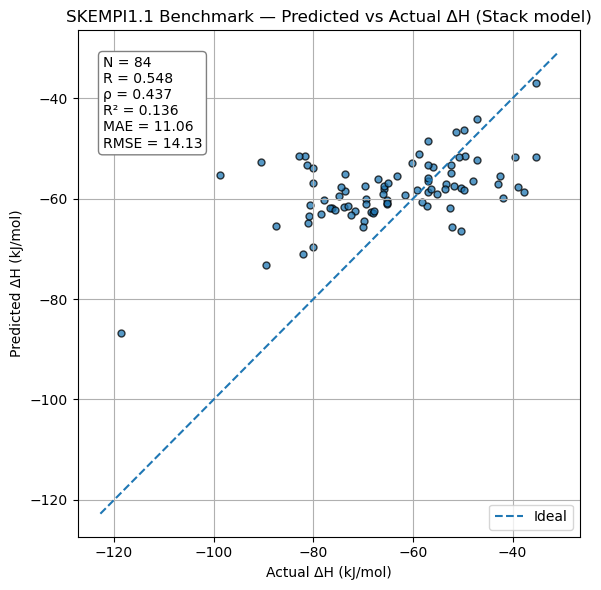

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

# --- Select data ---
y_true = df_eval["delta_H"].values
y_pred = df_eval["pred_stack"].values   # change to pred_blend3 if desired

# --- Metrics ---
R = pearsonr(y_true, y_pred)[0]
rho = spearmanr(y_true, y_pred)[0]
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.75, edgecolor="k", s=25)

mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
pad = 0.05 * (mx - mn)
plt.plot([mn - pad, mx + pad], [mn - pad, mx + pad], "--", label="Ideal")

plt.xlabel("Actual ΔH (kJ/mol)")
plt.ylabel("Predicted ΔH (kJ/mol)")
plt.title("SKEMPI1.1 Benchmark — Predicted vs Actual ΔH (Stack model)")

txt = (
    f"N = {len(y_true)}\n"
    f"R = {R:.3f}\n"
    f"ρ = {rho:.3f}\n"
    f"R² = {r2:.3f}\n"
    f"MAE = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}"
)

plt.annotate(
    txt,
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"),
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
